# Part a)

## Imports

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

## Parameters

In [28]:
# Kinetic parameters
mu_m = 0.9        # h^-1
Ks = 0.21        # g/L
KI = 1.5         # g/L
Yxs = 0.6        # g/g
KCL = 0.2        # mg/L
Yos = 160        # mg/g
M = 0.0314

# Reactor parameters
VL = 90          # L
G = 5000         # L/h
eps = 0.2
CLi = 6          # mg/L
CGi = 250        # mg/L
Si = 30          # g/L
VG = eps * VL
CL_limit = 3 * KCL

## Initial conditions

In [29]:
y0 = [1, 0, 6, 250]  # X, S, CL, CG

### Model equations

This cell defines the growth rate and the system of ODEs used to describe the continuous aerated fermenter.  
The growth rate depends on the substrate concentration, the dissolved oxygen concentration, and substrate inhibition.  
The ODE system then describes the time evolution of biomass \(X\), substrate \(S\), dissolved oxygen \(C_L\), and gas phase oxygen \(C_G\).

In [30]:
# Growth rate
def mu(S, CL):
    return mu_m * S / (Ks + S + S**2 / KI) * CL / (KCL + CL)

# ODE system
def system(t, y, F, KLa):
    X, S, CL, CG = y

    # Prevent numerical negative concentrations
    X = max(X, 0)
    S = max(S, 0)
    CL = max(CL, 0)
    CG = max(CG, 0)

    mu_val = mu(S, CL) if S > 0 else 0
    CL_star = M * CG

    dXdt = -F / VL * X + mu_val * X

    dSdt = F / VL * (Si - S) - (1 / Yxs) * mu_val * X

    dCLdt = (F / VL * (CLi - CL) - Yos / Yxs * mu_val * X + KLa * (CL_star - CL))

    dCGdt = (G / VG * (CGi - CG) - KLa * VL / VG * (CL_star - CL))

    return [dXdt, dSdt, dCLdt, dCGdt]

### Numerical solver

This cell defines a function that solves the ODE system for a given feed flow rate \(F\) and oxygen transfer coefficient \(K_La\).  
Since the system is stiff, the BDF method is used.  
The simulation is run long enough to reach steady state.

In [54]:
def simulate(F, KLa, t_end=600):
    t_eval = np.linspace(0, t_end, 1200)

    sol = solve_ivp(system, [0, t_end], y0, args=(F, KLa), method="BDF", rtol=1e-6, atol=1e-6, t_eval=t_eval)

    return sol

### Oxygen limitation criterion

This cell checks whether the process becomes oxygen limited.  
For each simulation, the minimum dissolved oxygen concentration is calculated.  
Then, the minimum value of \(K_La\) is found such that \(C_L\) stays above the oxygen limitation threshold \(3K_{CL}\).

In [32]:
# Minimum dissolved oxygen
def min_CL(F, KLa):
    sol = simulate(F, KLa)
    return np.min(sol.y[2])

# Search for minimum KLa
def find_min_KLa(F):
    def condition(KLa):
        return min_CL(F, KLa) - CL_limit

    # Increase upper bound if needed
    KLa_low = 0.01
    KLa_high = 70

    while condition(KLa_high) < 0:
        KLa_high *= 2

    return brentq(condition, KLa_low, KLa_high)

### Simulation for different feed flow rates

This cell varies the feed flow rate \(F\) between 6.5 and 10 L/h.  
For each value of \(F\), the minimum \(K_La\) needed to avoid oxygen limitation is calculated.  
The results are printed as a table with the corresponding minimum dissolved oxygen concentration.

In [33]:
F_values = np.linspace(6.5, 10, 8)

results = []

for F in F_values:
    KLa_needed = find_min_KLa(F)
    sol = simulate(F, KLa_needed)
    CL_min = np.min(sol.y[2])

    results.append([F, KLa_needed, CL_min])

print("F [L/h]      KLa_min [h^-1]      min(CL) [mg/L]")
for F, KLa_needed, CL_min in results:
    print(f"{F:6.2f}      {KLa_needed:12.3f}      {CL_min:12.3f}")

F [L/h]      KLa_min [h^-1]      min(CL) [mg/L]
  6.50           131.779             0.600
  7.00            16.016             0.600
  7.50            15.708             0.600
  8.00            15.366             0.600
  8.50            15.002             0.600
  9.00            14.627             0.600
  9.50            14.248             0.600
 10.00            13.871             0.600


### Growth kinetics analysis for \(F = 10\) L/h

This cell analyzes the growth kinetics for the case \(F = 10\) L/h.  
The growth rate \(\mu\) is calculated from the simulated substrate and dissolved oxygen concentrations.  
Then, \(\mu\) is plotted as a function of the substrate concentration \(S\) to show the effect of substrate inhibition.

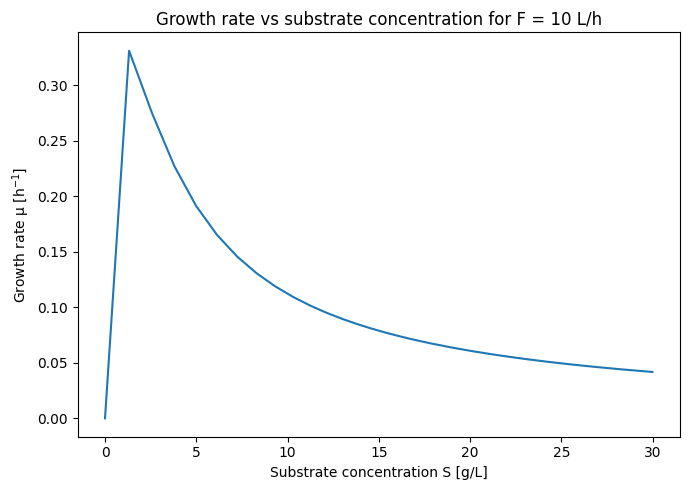

In [35]:
# Simulation
F_plot = 10
KLa_plot = find_min_KLa(F_plot)
sol = simulate(F_plot, KLa_plot)

X = sol.y[0]
S = sol.y[1]
CL = sol.y[2]

mu_values = mu(S, CL)

# Plot of growth rate vs substrate concentration
plt.figure(figsize=(7, 5))
plt.plot(S, mu_values)
plt.xlabel("Substrate concentration S [g/L]")
plt.ylabel("Growth rate μ [h$^{-1}$]")
plt.title("Growth rate vs substrate concentration for F = 10 L/h")
plt.grid(False)
plt.tight_layout()
plt.show()

# Part b)

## Batch operating conditions

In [36]:
F_batch = 0.0       # L/h
KLa_batch = 70.0   # h^-1

## Initial conditions

In [37]:
y0_batch = [1, 30, 6, 250]  # X, S, CL, CG

### Batch simulation

In [38]:
def simulate_batch(t_end=100):
    t_eval = np.linspace(0, t_end, 1000)

    sol = solve_ivp(system, [0, t_end], y0_batch, args=(F_batch, KLa_batch), method="BDF", rtol=1e-6, atol=1e-6, t_eval=t_eval)

    return sol

sol_b = simulate_batch()

# Extract results
t = sol_b.t
X = sol_b.y[0]
S = sol_b.y[1]
CL = sol_b.y[2]
CG = sol_b.y[3]

# Compute growth rate and OUR
mu_values = mu(S, CL)
OUR = (Yos / Yxs) * mu_values * X * VL

## Plots

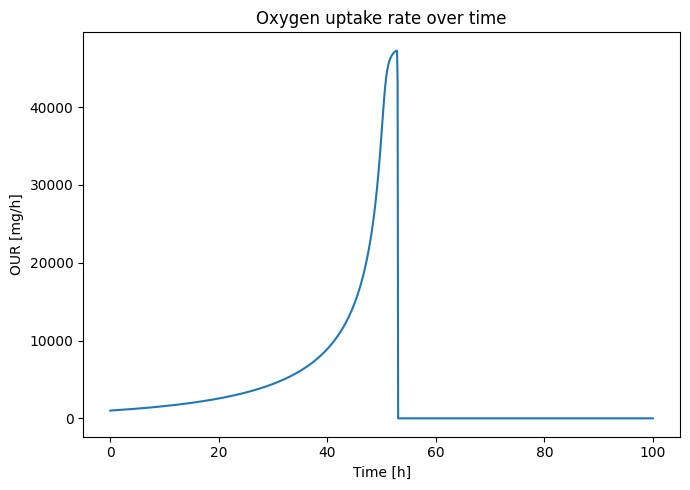

In [39]:
# Plot OUR over time
plt.figure(figsize=(7, 5))
plt.plot(t, OUR)
plt.xlabel("Time [h]")
plt.ylabel("OUR [mg/h]")
plt.title("Oxygen uptake rate over time")
plt.grid(False)
plt.tight_layout()
plt.show()

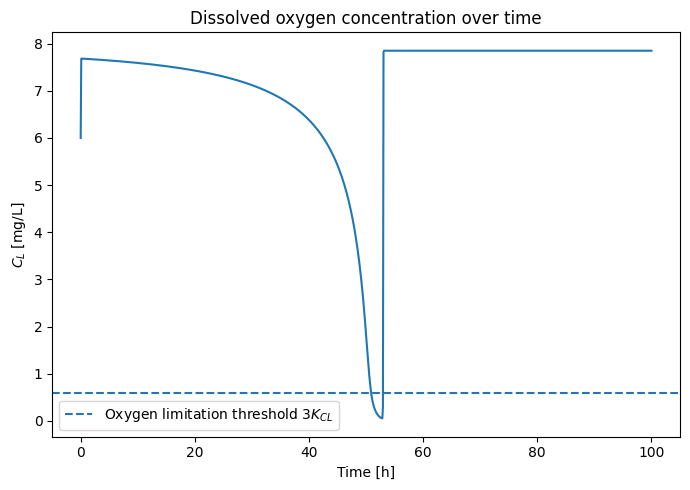

In [40]:
# Plot CL over time
plt.figure(figsize=(7, 5))
plt.plot(t, CL)
plt.axhline(3*KCL, linestyle="--", label=r"Oxygen limitation threshold $3K_{CL}$")
plt.xlabel("Time [h]")
plt.ylabel(r"$C_L$ [mg/L]")
plt.title("Dissolved oxygen concentration over time")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

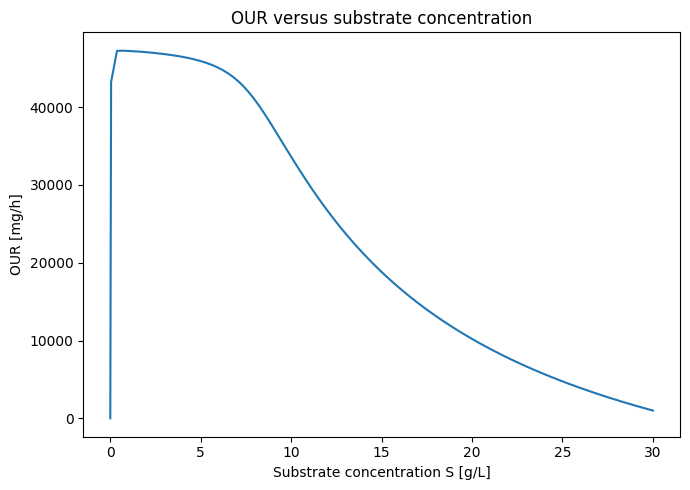

In [41]:
# Plot OUR versus S
plt.figure(figsize=(7, 5))
plt.plot(S, OUR)
plt.xlabel("Substrate concentration S [g/L]")
plt.ylabel("OUR [mg/h]")
plt.title("OUR versus substrate concentration")
plt.grid(False)
plt.tight_layout()
plt.show()

##  Numerical results

In [42]:
print(f"Minimum CL = {np.min(CL):.3f} mg/L")
print(f"Oxygen limitation threshold = {3*KCL:.3f} mg/L")
print(f"Maximum OUR = {np.max(OUR):.3f} mg/h")
print(f"Final substrate concentration = {S[-1]:.3f} g/L")
print(f"Final biomass concentration = {X[-1]:.3f} g/L")

Minimum CL = 0.053 mg/L
Oxygen limitation threshold = 0.600 mg/L
Maximum OUR = 47257.887 mg/h
Final substrate concentration = -0.000 g/L
Final biomass concentration = 19.000 g/L


# Part c)

### OUR from cellular oxygen consumption

This cell calculates the oxygen uptake rate from the biological consumption term.  
This corresponds to the oxygen consumed by the cells during growth.

In [43]:
# OUR calculated from the liquid phase consumption term, as in part b
OUR_b = (Yos / Yxs) * mu_values * X * VL

### OUR from gas phase concentration difference

This cell estimates the oxygen uptake rate using the difference between inlet and outlet gas phase oxygen concentrations.  
This gives an indirect measurement of oxygen consumption based on the gas phase oxygen balance.

In [44]:
# OUR estimated from the inlet/outlet gas phase oxygen difference
OUR_gas = G * (CGi - CG)

### Numerical comparison

This cell compares the maximum and final OUR values obtained with the two methods.  
The objective is to check whether the cellular oxygen consumption and the gas phase balance give similar results.

In [45]:
print(f"Maximum OUR from part b) = {np.max(OUR_b):.3f} mg/h")
print(f"Maximum OUR from gas phase = {np.max(OUR_gas):.3f} mg/h")
print(f"Final OUR from part b) = {OUR_b[-1]:.3f} mg/h")
print(f"Final OUR from gas phase = {OUR_gas[-1]:.3f} mg/h")

Maximum OUR from part b) = 47257.887 mg/h
Maximum OUR from gas phase = 47253.677 mg/h
Final OUR from part b) = -0.222 mg/h
Final OUR from gas phase = -0.000 mg/h


## Comparison plot

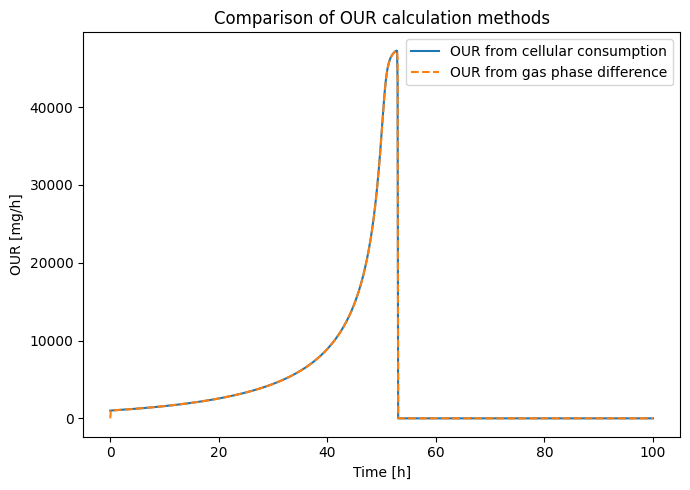

In [46]:
plt.figure(figsize=(7, 5))
plt.plot(t, OUR_b, label="OUR from cellular consumption")
plt.plot(t, OUR_gas, "--", label="OUR from gas phase difference")
plt.xlabel("Time [h]")
plt.ylabel("OUR [mg/h]")
plt.title("Comparison of OUR calculation methods")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Part d)

## Operationg conditions

In [47]:
F_d = 6.5        # L/h
KLa_d = 70.0     # h^-1
Si_values = [30, 100]  # g/L

## Initial conditions

In [48]:
y0_d = [1, 0, 6, 250]  # X, S, CL, CG

### Modified ODE system

This cell defines a modified ODE system where the substrate feed concentration can be changed.  
This allows the reactor behavior to be compared for different feed substrate concentrations.

In [49]:
def system_part_d(t, y, F, KLa, Si_feed):
    X, S, CL, CG = y

    X = max(X, 0)
    S = max(S, 0)
    CL = max(CL, 0)
    CG = max(CG, 0)

    mu_val = mu(S, CL) if S > 0 else 0
    CL_star = M * CG

    dXdt = -F / VL * X + mu_val * X

    dSdt = F / VL * (Si_feed - S) - (1 / Yxs) * mu_val * X

    dCLdt = (F / VL * (CLi - CL) - Yos / Yxs * mu_val * X + KLa * (CL_star - CL))

    dCGdt = (G / VG * (CGi - CG) - KLa * VL / VG * (CL_star - CL))

    return [dXdt, dSdt, dCLdt, dCGdt]

### Simulations

This cell simulates the CSTR for two different substrate feed concentrations: 30 g/L and 100 g/L.  
For each case, the biomass, substrate, dissolved oxygen, gas phase oxygen, growth rate, and OUR are calculated and stored for comparison.

In [50]:
results_d = {}

for Si_feed in Si_values:
    sol = solve_ivp(system_part_d, [0, 600], y0_d, args=(F_d, KLa_d, Si_feed), method="BDF", rtol=1e-6, atol=1e-6, t_eval=np.linspace(0, 600, 1500))

    t = sol.t
    X = sol.y[0]
    S = sol.y[1]
    CL = sol.y[2]
    CG = sol.y[3]

    mu_values = mu(S, CL)
    OUR = (Yos / Yxs) * mu_values * X * VL

    results_d[Si_feed] = {"t": t, "X": X, "S": S, "CL": CL, "CG": CG, "mu": mu_values, "OUR": OUR}

## Numerical comparison 

In [51]:
for Si_feed in Si_values:
    data = results_d[Si_feed]

    print(f"\nFeed substrate concentration Si = {Si_feed} g/L")
    print(f"Minimum CL = {np.min(data['CL']):.3f} mg/L")
    print(f"Final CL = {data['CL'][-1]:.3f} mg/L")
    print(f"Maximum OUR = {np.max(data['OUR']):.3f} mg/h")
    print(f"Final OUR = {data['OUR'][-1]:.3f} mg/h")
    print(f"Final S = {data['S'][-1]:.3f} g/L")
    print(f"Final X = {data['X'][-1]:.3f} g/L")


Feed substrate concentration Si = 30 g/L
Minimum CL = 0.096 mg/L
Final CL = 2.709 mg/L
Maximum OUR = 47033.738 mg/h
Final OUR = 31179.380 mg/h
Final S = 0.020 g/L
Final X = 17.988 g/L

Feed substrate concentration Si = 100 g/L
Minimum CL = 6.000 mg/L
Final CL = 7.848 mg/L
Maximum OUR = 8562.875 mg/h
Final OUR = -0.000 mg/h
Final S = 100.000 g/L
Final X = -0.000 g/L


## Plot OUR comparison

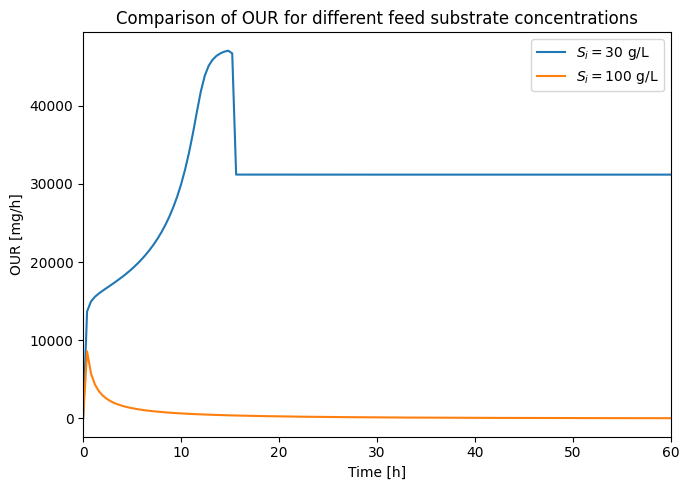

In [52]:
plt.figure(figsize=(7, 5))

for Si_feed in Si_values:
    data = results_d[Si_feed]
    plt.plot(data["t"], data["OUR"], label=fr"$S_i = {Si_feed}$ g/L")

plt.xlabel("Time [h]")
plt.ylabel("OUR [mg/h]")
plt.xlim(0, 60)
plt.title("Comparison of OUR for different feed substrate concentrations")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

## Plot CL comparison

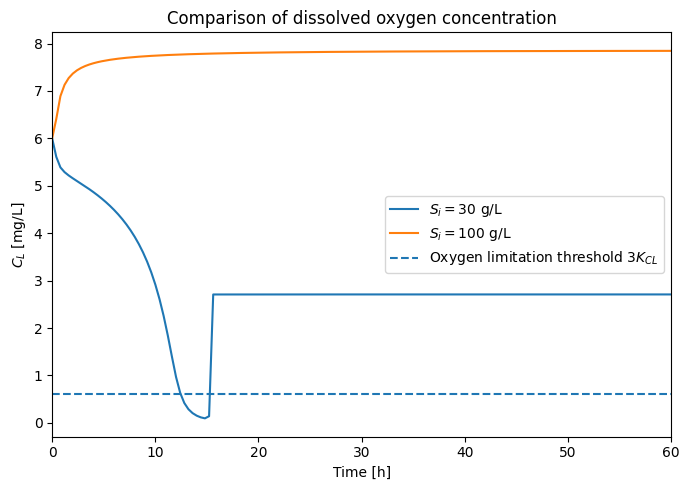

In [53]:
plt.figure(figsize=(7, 5))

for Si_feed in Si_values:
    data = results_d[Si_feed]
    plt.plot(data["t"], data["CL"], label=fr"$S_i = {Si_feed}$ g/L")

plt.axhline(3*KCL, linestyle="--", label=r"Oxygen limitation threshold $3K_{CL}$")

plt.xlabel("Time [h]")
plt.ylabel(r"$C_L$ [mg/L]")
plt.xlim(0, 60)
plt.title("Comparison of dissolved oxygen concentration")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()